# Chapter 10: Introduction to Artificial Neural Networks with Keras

In [1]:
from typing import List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np


def plot_decision_boundary(
        clf,
        Xs: Sequence[np.ndarray],
        ys: Sequence[int],
        feature_names=("X1", "X2"),
        titles: Optional[List[str]] = None,
        suptitle: Optional[str] = None,
) -> None:
    n_subplots = len(Xs)
    fig, axes = plt.subplots(ncols=n_subplots, figsize=[6 * n_subplots, 5])

    if titles is None:
        titles = [None] * n_subplots

    if not isinstance(axes, np.ndarray):
        axes = [axes]

    X_min, X_max = np.min(np.concatenate(Xs, axis=0), axis=0) - .5, np.max(np.concatenate(Xs, axis=0), axis=0) + .5
    h = .2
    xx, yy = np.meshgrid(np.arange(X_min[0], X_max[0], h), np.arange(X_min[1], X_max[1], h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    for X, y, ax, title in zip(Xs, ys, axes, titles):
        ax.scatter(X[:, 0], X[:, 1], c=y)
        ax.contourf(xx, yy, Z, alpha=0.5)
        ax.set(xlabel=feature_names[0], ylabel=feature_names[1], title=title)

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize="x-large", fontweight="bold")

### 10.1 From Biological to Artificial Neurons

##### 10.1.1 Biological Neurons

##### 10.1.2 Logical Computations with Neurons

##### 10.1.3 The Perceptron

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:, [2, 3]]
y = (iris.target == 0).astype(int)
feature_names = [iris.feature_names[idx] for idx in [2, 3]]

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)
per_clf.score(X, y)

1.0

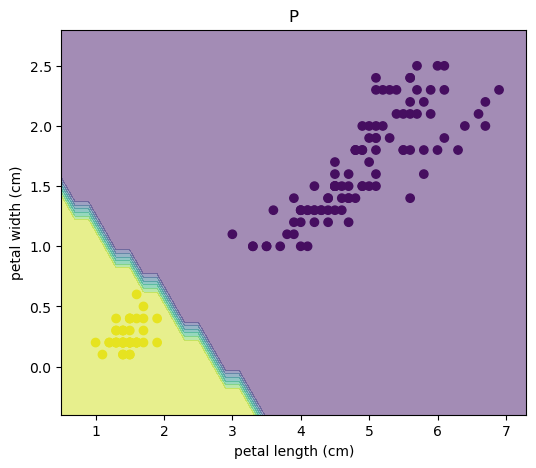

In [3]:
plot_decision_boundary(clf=per_clf, Xs=[X], ys=[y], feature_names=feature_names,
                       titles="Perceptron on the Iris Dataset")
plt.show()

##### 10.1.4 The Multilayer Perceptron and Backpropagation

##### 10.1.5 Regression MLPs

##### 10.1.6 Classification MLPs

### 10.2 Implementing MLPs with Keras

##### 10.2.1 Installing TensorFlow 2

In [4]:
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)
tf.config.list_physical_devices('GPU')

2.4.1
2.4.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
physical_devices = tf.config.list_physical_devices('GPU')
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

##### 10.2.2 Building an Image Classifier Using the Sequential API

Set seeds

In [6]:
import random
import numpy as np
import tensorflow as tf

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

Using Keras to load the dataset.

In [7]:
# Load MNINST Fashion dataset
from tensorflow import keras

fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [8]:
# Add class names
class_names = np.array(["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag",
                        "Ankle boot"])

In [9]:
# Inspect data dimension
print(f"Shape of X_train_full: {X_train_full.shape}")
print(f"Data type X_train_full: {X_train_full.dtype}")
print(f"Class of the first item: {class_names[y_train_full[0]]}")

Shape of X_train_full: (60000, 28, 28)
Data type X_train_full: uint8
Class of the first item: Ankle boot


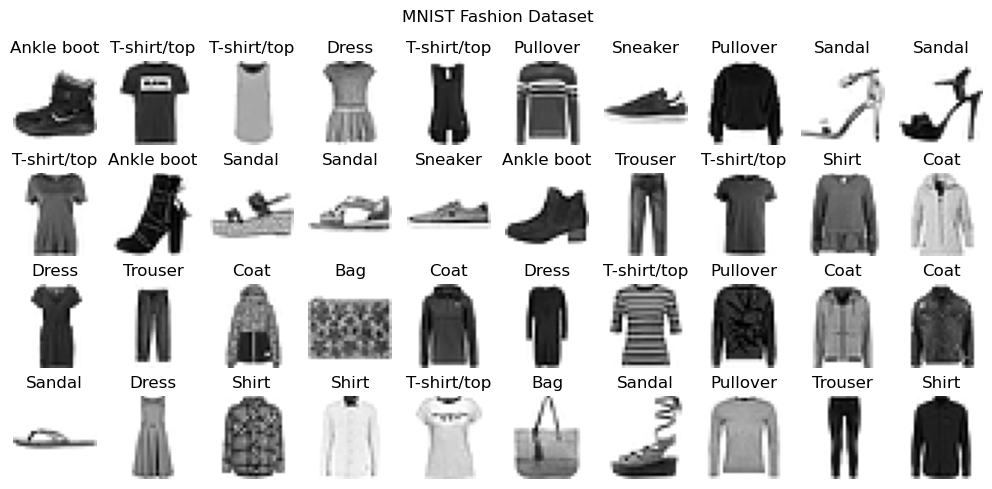

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence


# Visualize data
def visualize_images(images: Sequence[Sequence[float]], labels: Sequence[str], cmap: str = "gray",
                     n_cols: int = 5) -> None:
    """Visualize images

    Parameters
    ----------
    images : Sequence[Sequence[float]]
        Input images in shape (n_images, n_pixels_in_row, n_pixels_col). Pixel values should be normalized to 0~1 float
        or 0~255 int.
    labels : Sequence[str]
        Labels of each images.
    cmap : str
        Color map.
    n_cols : int
        Number of images per row. Default 5.

    Returns
    -------
    None

    """
    n_images = len(images)
    n_rows = round(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, squeeze=False, figsize=(10, 1 * n_rows + 1))
    for ax, image, label in zip(axes.ravel(), images, labels):
        ax.imshow(image, cmap=cmap)
        ax.set_title(label)
        ax.axis("off")

    fig.suptitle("MNIST Fashion Dataset")
    plt.tight_layout()


visualize_images(X_train_full[:40], class_names[y_train_full[:40]], cmap="gray_r", n_cols=10)
plt.show()

In [11]:
# Normalize data
X_train, X_valid = X_train_full[:-5000] / 255., X_train_full[-5000:] / 255.
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

Creating the model using the sequential API

In [12]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


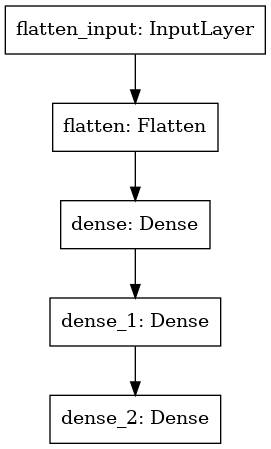

In [13]:
keras.utils.plot_model(model)

In [14]:
model.layers

In [15]:
model.layers[1]

In [16]:
model.get_layer("dense")

In [17]:
hidden1 = model.get_layer("dense")
weights, biases = hidden1.get_weights()
weights.shape

(784, 300)

In [18]:
biases.shape

(300,)

In [19]:
weights

array([[ 0.02448617, -0.00877795, -0.02189048, ..., -0.02766046,
         0.03859074, -0.06889391],
       [ 0.00476504, -0.03105379, -0.0586676 , ...,  0.00602964,
        -0.02763776, -0.04165364],
       [-0.06189284, -0.06901957,  0.07102345, ..., -0.04238207,
         0.07121518, -0.07331658],
       ...,
       [-0.03048757,  0.02155137, -0.05400612, ..., -0.00113463,
         0.00228987,  0.05581069],
       [ 0.07061854, -0.06960931,  0.07038955, ..., -0.00384101,
         0.00034875,  0.02878492],
       [-0.06022581,  0.01577859, -0.02585464, ..., -0.00527829,
         0.00272203, -0.06793761]], dtype=float32)

In [20]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

Compiling the model

In [21]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

Training and evaluating the model

In [22]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 [==============================] - 3s 2ms/step - loss: 1.0223 - accuracy: 0.6794 - val_loss: 0.4960 - val_accuracy: 0.8332
Epoch 2/30
1719/1719 [==============================] - 2s 1ms/step - loss: 0.4952 - accuracy: 0.8280 - val_loss: 0.4560 - val_accuracy: 0.8386
Epoch 3/30
1719/1719 [==============================] - 2s 1ms/step - loss: 0.4437 - accuracy: 0.8465 - val_loss: 0.4230 - val_accuracy: 0.8560
Epoch 4/30
1719/1719 [==============================] - 3s 1ms/step - loss: 0.4117 - accuracy: 0.8557 - val_loss: 0.3969 - val_accuracy: 0.8610
Epoch 5/30
1719/1719 [==============================] - 2s 1ms/step - loss: 0.3949 - accuracy: 0.8602 - val_loss: 0.3889 - val_accuracy: 0.8612
Epoch 6/30
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3839 - accuracy: 0.8656 - val_loss: 0.3901 - val_accuracy: 0.8620
Epoch 7/30
1719/1719 [==============================] - 3s 2ms/step - loss: 0.3644 - accuracy: 0.8693 - val_loss: 0.3721 - val_accuracy:

In [23]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 1719}

In [24]:
history.epoch

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

In [25]:
history.history

{'loss': [0.7220508456230164,
  0.4826348125934601,
  0.4369766414165497,
  0.4119802415370941,
  0.39087170362472534,
  0.37502238154411316,
  0.36290591955184937,
  0.35146647691726685,
  0.340565949678421,
  0.33068206906318665,
  0.3224649727344513,
  0.3145119249820709,
  0.3073022663593292,
  0.30034539103507996,
  0.2938898205757141,
  0.28698354959487915,
  0.28254082798957825,
  0.2758271098136902,
  0.2711571156978607,
  0.26634353399276733,
  0.2612937092781067,
  0.2563360333442688,
  0.25195226073265076,
  0.24703410267829895,
  0.2428363710641861,
  0.2392590194940567,
  0.2342144399881363,
  0.23136968910694122,
  0.22667446732521057,
  0.22339917719364166],
 'accuracy': [0.7649272680282593,
  0.8329272866249084,
  0.8478909134864807,
  0.8560545444488525,
  0.8631272912025452,
  0.8689091205596924,
  0.8707818388938904,
  0.8752181529998779,
  0.8791272640228271,
  0.8815818428993225,
  0.885309100151062,
  0.887072741985321,
  0.8902727365493774,
  0.8921818137168884,


In [26]:
import pandas as pd

df_history = pd.DataFrame(history.history)
df_history

,loss,accuracy,val_loss,val_accuracy
0,0.722051,0.764927,0.496046,0.8332
1,0.482635,0.832927,0.455986,0.8386
2,0.436977,0.847891,0.423030,0.8560
3,0.411980,0.856055,0.396851,0.8610
4,0.390872,0.863127,0.388873,0.8612
5,0.375022,0.868909,0.390106,0.8620
6,0.362906,0.870782,0.372109,0.8696
7,0.351466,0.875218,0.379388,0.8600
8,0.340566,0.879127,0.351102,0.8734
9,0.330682,0.881582,0.353699,0.8734


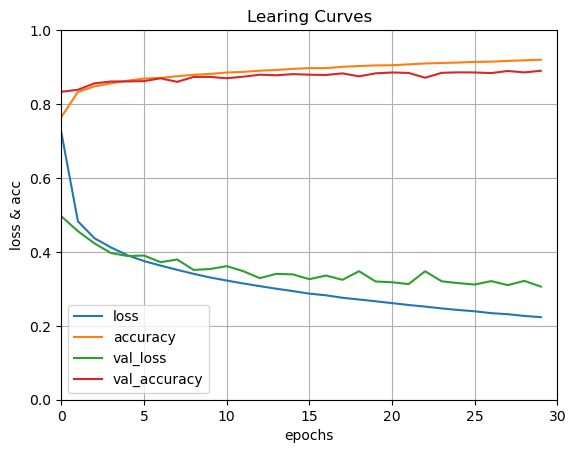

In [27]:
import matplotlib.pyplot as plt

df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.params["epochs"]), ylim=(0, 1), xlabel="epochs", ylabel="loss & acc", title="Learing Curves")
ax.grid()
plt.show()

Corrected curves

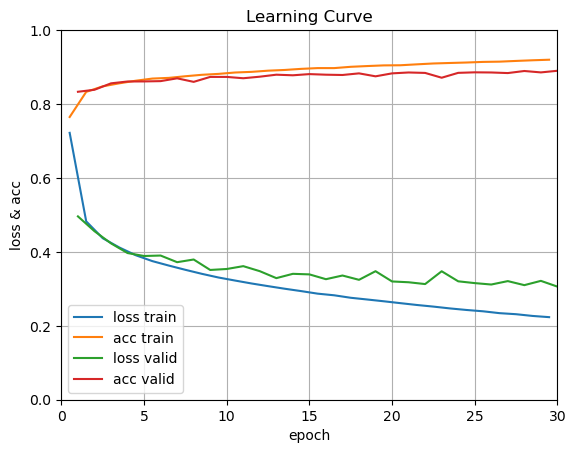

In [28]:
epochs = np.asarray(history.epoch)
epochs_train = epochs + 0.5
epochs_valid = epochs + 1

loss_train = df_history.loss
loss_valid = df_history.val_loss

acc_train = df_history.accuracy
acc_valid = df_history.val_accuracy

fig, ax = plt.subplots()
ax.plot(epochs_train, loss_train, label="loss train")
ax.plot(epochs_train, acc_train, label="acc train")
ax.plot(epochs_valid, loss_valid, label="loss valid")
ax.plot(epochs_valid, acc_valid, label="acc valid")
ax.set(xlim=(0, 30), ylim=(0, 1), xlabel="epoch", ylabel="loss & acc", title="Learning Curve")
ax.legend()
ax.grid()
plt.show()

In [29]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 1ms/step - loss: 59.8139 - accuracy: 0.8529


[59.81391906738281, 0.8529000282287598]

Using the model to make predictions

In [30]:
X_new = X_test[:10]
y_new_proba = model.predict(X_new)
y_new = model.predict_classes(X_new)
y_new = np.argmax(y_new_proba, axis=1)
y_new

/home/yu/anaconda3/envs/data-science/lib/python3.9/site-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

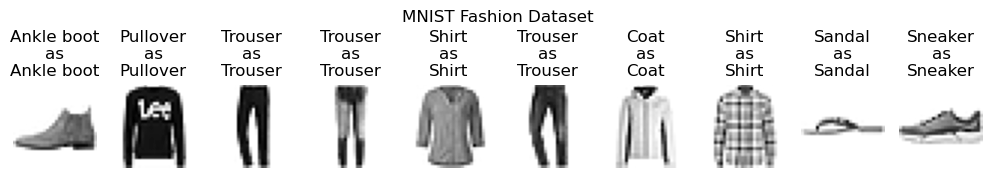

In [31]:
labels = [f"{name_true}\nas\n{name_pred}" for name_true, name_pred in zip(class_names[y_test[:10]], class_names[y_new])]

visualize_images(X_new, labels=labels, cmap="gray_r", n_cols=10)
plt.show()

##### 10.2.3 Regression MLP Using Sequential API

In [32]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

In [33]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [34]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(optimizer="sgd", loss="mean_squared_error")
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 30)                270       
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 31        
Total params: 301
Trainable params: 301
Non-trainable params: 0
_________________________________________________________________


In [35]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 [==============================] - 1s 1ms/step - loss: 1.2270 - val_loss: 0.6806
Epoch 2/20
363/363 [==============================] - 0s 1ms/step - loss: 0.6066 - val_loss: 0.5710
Epoch 3/20
363/363 [==============================] - 0s 1ms/step - loss: 0.6332 - val_loss: 0.4964
Epoch 4/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4747 - val_loss: 0.4785
Epoch 5/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4391 - val_loss: 0.4615
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4368 - val_loss: 0.4553
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4267 - val_loss: 0.4433
Epoch 8/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4165 - val_loss: 0.4446
Epoch 9/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4189 - val_loss: 0.4326
Epoch 10/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4096 - val_loss: 0.4306

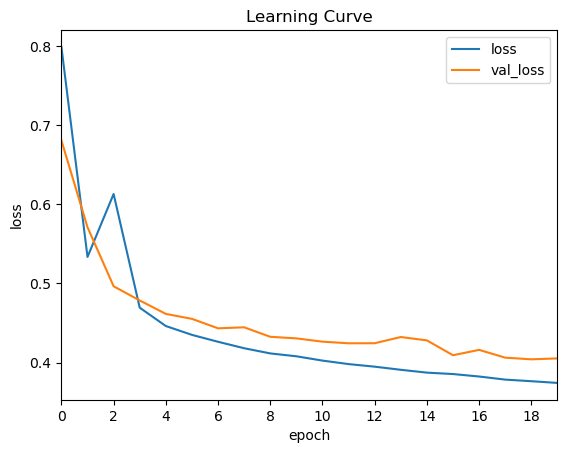

In [36]:
from matplotlib.ticker import MaxNLocator

df_history = pd.DataFrame(history.history)
df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.epoch[-1]), xlabel="epoch", ylabel="loss", title="Learning Curve")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [37]:
model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 838us/step - loss: 0.3829


0.38292133808135986

In [38]:
X_new = X_test[:3]
y_new = y_new[:3]
y_new

array([9, 2, 1])

In [39]:
y_pred = model.predict(X_new)
y_pred

array([[0.6249132],
       [1.7954626],
       [3.5576253]], dtype=float32)

##### 10.2.4 Building Complex Models Using the Functional API

Sequential model

In [40]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
output = keras.layers.Dense(1)(hidden2)
model = keras.Model(inputs=[input_], outputs=[output])
model.compile(optimizer="sgd", loss="mean_squared_error")
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 8)]               0         
_________________________________________________________________
dense_5 (Dense)              (None, 30)                270       
_________________________________________________________________
dense_6 (Dense)              (None, 30)                930       
_________________________________________________________________
dense_7 (Dense)              (None, 1)                 31        
Total params: 1,231
Trainable params: 1,231
Non-trainable params: 0
_________________________________________________________________


In [41]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 1.3335 - val_loss: 0.6381
Epoch 2/20
363/363 [==============================] - 0s 1ms/step - loss: 0.6071 - val_loss: 0.7685
Epoch 3/20
363/363 [==============================] - 0s 1ms/step - loss: 1.0429 - val_loss: 0.4787
Epoch 4/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4528 - val_loss: 0.4558
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4259 - val_loss: 0.4358
Epoch 6/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4065 - val_loss: 0.4231
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.3903 - val_loss: 0.4109
Epoch 8/20
363/363 [==============================] - 0s 1ms/step - loss: 0.3790 - val_loss: 0.4141
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.3764 - val_loss: 0.4018
Epoch 10/20
363/363 [==============================] - 0s 1ms/step - loss: 0.3723 - val_loss: 0.3987

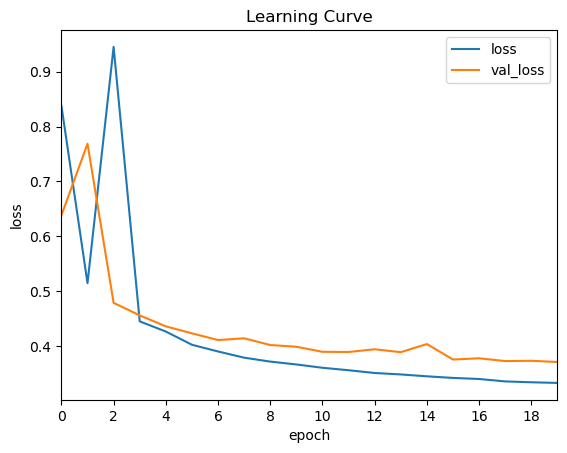

In [42]:
from matplotlib.ticker import MaxNLocator

df_history = pd.DataFrame(history.history)
df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.epoch[-1]), xlabel="epoch", ylabel="loss", title="Learning Curve")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [43]:
model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 869us/step - loss: 0.3476


0.347589910030365

Residual model

In [44]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])
model.compile(optimizer="sgd", loss="mean_squared_error")
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 8)]          0                                            
__________________________________________________________________________________________________
dense_8 (Dense)                 (None, 30)           270         input_2[0][0]                    
__________________________________________________________________________________________________
dense_9 (Dense)                 (None, 30)           930         dense_8[0][0]                    
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 38)           0           input_2[0][0]                    
                                                                 dense_9[0][0]              

In [45]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 1.7801 - val_loss: 1.8347
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 2.6641 - val_loss: 36.2731
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 4/20
363/363 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 10/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 11/20
363/363 [=========================

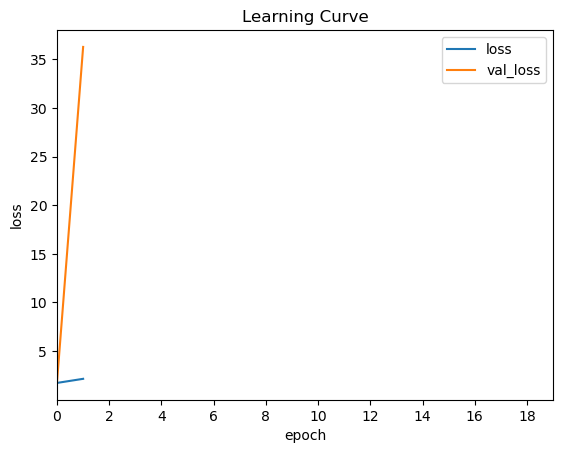

In [46]:
from matplotlib.ticker import MaxNLocator

df_history = pd.DataFrame(history.history)
df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.epoch[-1]), xlabel="epoch", ylabel="loss", title="Learning Curve")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [47]:
model.evaluate(X_test, y_test)

162/162 [==============================] - 0s 827us/step - loss: nan


nan

Multiple inputs

In [48]:
X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test[:3, :5], X_test[:3, 2:]
y_new = y_test[:3]

In [49]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.Model(inputs=[input_A, input_B], outputs=[output])
model.compile(optimizer="sgd", loss="mean_squared_error")
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
deep_input (InputLayer)         [(None, 6)]          0                                            
__________________________________________________________________________________________________
dense_11 (Dense)                (None, 30)           210         deep_input[0][0]                 
__________________________________________________________________________________________________
wide_input (InputLayer)         [(None, 5)]          0                                            
__________________________________________________________________________________________________
dense_12 (Dense)                (None, 30)           930         dense_11[0][0]                   
____________________________________________________________________________________________

In [50]:
history = model.fit((X_train_A, X_train_B), y_train, epochs=20, validation_data=([X_valid_A, X_valid_B], y_valid))

Epoch 1/20
363/363 [==============================] - 1s 1ms/step - loss: 1.4151 - val_loss: 0.5621
Epoch 2/20
363/363 [==============================] - 0s 1ms/step - loss: 0.5602 - val_loss: 0.5080
Epoch 3/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4807 - val_loss: 0.4851
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4737 - val_loss: 0.4790
Epoch 5/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4469 - val_loss: 0.4909
Epoch 6/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4514 - val_loss: 0.4708
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4353 - val_loss: 0.4457
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4255 - val_loss: 0.4526
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4300 - val_loss: 0.4334
Epoch 10/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4062 - val_loss: 0.4276

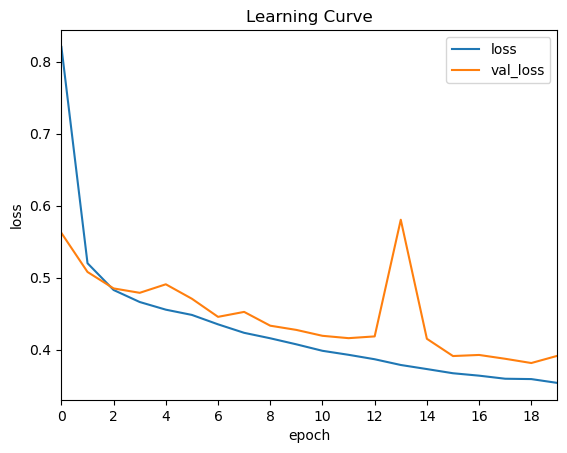

In [51]:
from matplotlib.ticker import MaxNLocator

df_history = pd.DataFrame(history.history)
df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.epoch[-1]), xlabel="epoch", ylabel="loss", title="Learning Curve")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [52]:
model.evaluate((X_test_A, X_test_B), y_test)

162/162 [==============================] - 0s 913us/step - loss: 0.3690


0.3690488040447235

Multiple output

In [53]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])
model.compile(optimizer="sgd", loss="mse", loss_weights={"main_output": 0.9, "aux_output": 0.1})
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
deep_input (InputLayer)         [(None, 6)]          0                                            
__________________________________________________________________________________________________
dense_13 (Dense)                (None, 30)           210         deep_input[0][0]                 
__________________________________________________________________________________________________
wide_input (InputLayer)         [(None, 5)]          0                                            
__________________________________________________________________________________________________
dense_14 (Dense)                (None, 30)           930         dense_13[0][0]                   
____________________________________________________________________________________________

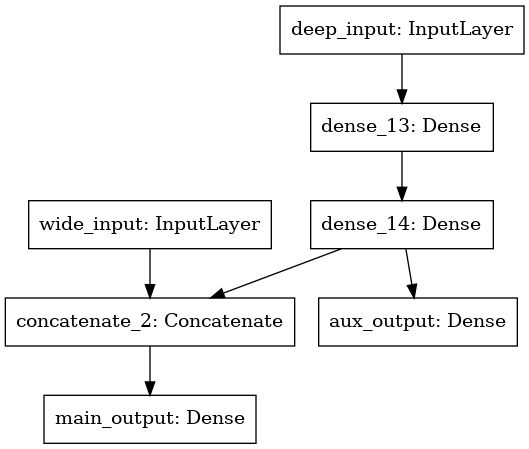

In [54]:
keras.utils.plot_model(model)

In [55]:
history = model.fit((X_train_A, X_train_B), (y_train, y_train), epochs=20, validation_data=([X_valid_A, X_valid_B], (y_valid, y_valid)))

Epoch 1/20
363/363 [==============================] - 1s 3ms/step - loss: 1.7196 - main_output_loss: 1.5282 - aux_output_loss: 3.4420 - val_loss: 0.6809 - val_main_output_loss: 0.6155 - val_aux_output_loss: 1.2690
Epoch 2/20
363/363 [==============================] - 1s 3ms/step - loss: 0.6633 - main_output_loss: 0.6051 - aux_output_loss: 1.1862 - val_loss: 0.5758 - val_main_output_loss: 0.5255 - val_aux_output_loss: 1.0285
Epoch 3/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5447 - main_output_loss: 0.4985 - aux_output_loss: 0.9601 - val_loss: 0.5335 - val_main_output_loss: 0.4955 - val_aux_output_loss: 0.8764
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5169 - main_output_loss: 0.4828 - aux_output_loss: 0.8241 - val_loss: 0.5274 - val_main_output_loss: 0.4997 - val_aux_output_loss: 0.7767
Epoch 5/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5093 - main_output_loss: 0.4848 - aux_output_loss: 0.7302 - val_loss

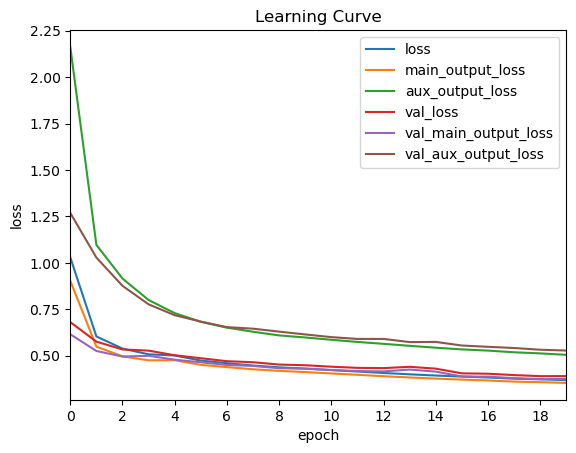

In [56]:
from matplotlib.ticker import MaxNLocator

df_history = pd.DataFrame(history.history)
df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.epoch[-1]), xlabel="epoch", ylabel="loss", title="Learning Curve")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [57]:
model.evaluate((X_test_A, X_test_B), (y_test, y_test))

162/162 [==============================] - 0s 1ms/step - loss: 0.3749 - main_output_loss: 0.3618 - aux_output_loss: 0.4921


[0.3748583495616913, 0.3618277311325073, 0.4921334683895111]

In [58]:
model.predict([X_new_A, X_new_B])

[array([[0.49903625],
        [1.8841225 ],
        [3.5242846 ]], dtype=float32),
 array([[0.6451944],
        [2.1127553],
        [3.0753992]], dtype=float32)]

In [59]:
y_new

array([0.477  , 0.458  , 5.00001])

In [60]:
path_model_h5 = "multi_input_output_model.h5"
model.save(path_model_h5)

In [61]:
model = keras.models.load_model(path_model_h5)

##### 10.2.5 Using the Subclassing API to Build Dynamic Models

In [62]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units: int = 30, activation: str = "relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel()
model.compile(optimizer="sgd", loss="mse", loss_weights=(0.9, 0.1))

In [63]:
history = model.fit([X_train_A, X_train_B], [y_train, y_train], epochs=20)

Epoch 1/20
363/363 [==============================] - 1s 1ms/step - loss: 1.6074 - output_1_loss: 1.4992 - output_2_loss: 2.5814
Epoch 2/20
363/363 [==============================] - 1s 1ms/step - loss: 0.6384 - output_1_loss: 0.5688 - output_2_loss: 1.2643
Epoch 3/20
363/363 [==============================] - 1s 1ms/step - loss: 0.5585 - output_1_loss: 0.4996 - output_2_loss: 1.0887
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5294 - output_1_loss: 0.4833 - output_2_loss: 0.9448
Epoch 5/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4738 - output_1_loss: 0.4355 - output_2_loss: 0.8190
Epoch 6/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4723 - output_1_loss: 0.4411 - output_2_loss: 0.7532
Epoch 7/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4519 - output_1_loss: 0.4247 - output_2_loss: 0.6969
Epoch 8/20
363/363 [==============================] - 1s 1ms/step - loss: 0.4417 - output_1_loss:

In [64]:
model.summary()

Model: "wide_and_deep_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_15 (Dense)             multiple                  210       
_________________________________________________________________
dense_16 (Dense)             multiple                  930       
_________________________________________________________________
dense_17 (Dense)             multiple                  36        
_________________________________________________________________
dense_18 (Dense)             multiple                  31        
Total params: 1,207
Trainable params: 1,207
Non-trainable params: 0
_________________________________________________________________


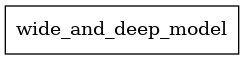

In [65]:
keras.utils.plot_model(model)

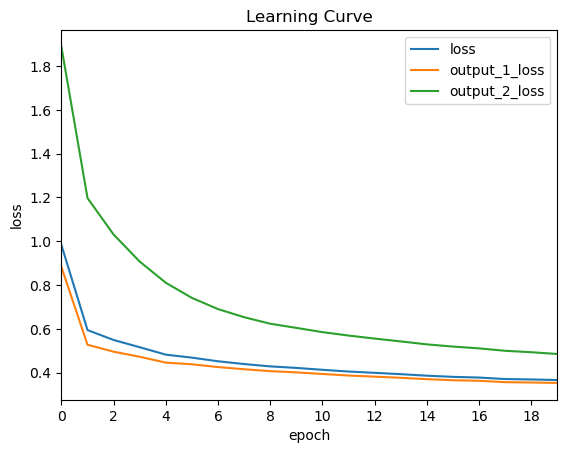

In [66]:
from matplotlib.ticker import MaxNLocator

df_history = pd.DataFrame(history.history)
df_history.plot()
ax = plt.gca()
ax.set(xlim=(0, history.epoch[-1]), xlabel="epoch", ylabel="loss", title="Learning Curve")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [67]:
model.evaluate((X_test_A, X_test_B), (y_test, y_test))

162/162 [==============================] - 0s 1ms/step - loss: 0.3710 - output_1_loss: 0.3588 - output_2_loss: 0.4807


[0.3709951341152191, 0.35880565643310547, 0.4807001054286957]

In [68]:
model.predict([X_new_A, X_new_B])

(array([[0.57313657],
        [1.5532879 ],
        [3.5808985 ]], dtype=float32),
 array([[0.7292218],
        [1.7518393],
        [2.8106563]], dtype=float32))

In [69]:
y_new

array([0.477  , 0.458  , 5.00001])

##### 10.2.6 Saving and Restoring a Model

In [70]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model_initial = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])
model = keras.models.clone_model(model_initial)
model.compile(optimizer="sgd", loss="mse", loss_weights={"main_output": 0.9, "aux_output": 0.1})

In [71]:
history = model.fit((X_train_A, X_train_B), (y_train, y_train), epochs=20, validation_data=([X_valid_A, X_valid_B], (y_valid, y_valid)))

Epoch 1/20
363/363 [==============================] - 2s 3ms/step - loss: 1.3792 - main_output_loss: 1.2383 - aux_output_loss: 2.6468 - val_loss: 0.6665 - val_main_output_loss: 0.5898 - val_aux_output_loss: 1.3566
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6547 - main_output_loss: 0.5863 - aux_output_loss: 1.2706 - val_loss: 0.5869 - val_main_output_loss: 0.5353 - val_aux_output_loss: 1.0517
Epoch 3/20
363/363 [==============================] - 1s 3ms/step - loss: 0.6088 - main_output_loss: 0.5644 - aux_output_loss: 1.0085 - val_loss: 0.5332 - val_main_output_loss: 0.4925 - val_aux_output_loss: 0.8995
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5180 - main_output_loss: 0.4815 - aux_output_loss: 0.8461 - val_loss: 0.5069 - val_main_output_loss: 0.4743 - val_aux_output_loss: 0.7998
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4673 - main_output_loss: 0.4368 - aux_output_loss: 0.7420 - val_loss

In [72]:
path_model_h5 = "multi_input_output_model.h5"
model.save(path_model_h5)

In [73]:
model = keras.models.load_model(path_model_h5)

##### 10.2.7 Using Callbacks

In [74]:
model = keras.models.clone_model(model)
model = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])
model.compile(optimizer="sgd", loss="mse", loss_weights={"main_output": 0.9, "aux_output": 0.1})

In [75]:
# Customized callback
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print(f"\nval/train: {logs['val_loss']/logs['loss']:.2f}")

print_val_train_ratio_cb = PrintValTrainRatioCallback()
checkpoint_cb = keras.callbacks.ModelCheckpoint(path_model_h5, save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

In [76]:
# Model check point and early stopping
history = model.fit([X_train_A, X_train_B], [y_train, y_train], epochs=20, validation_data=([X_valid_A, X_valid_B], (y_valid, y_valid)), callbacks=[checkpoint_cb, early_stopping_cb, print_val_train_ratio_cb])
model = keras.models.load_model(path_model_h5)

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 1.5118 - main_output_loss: 1.3540 - aux_output_loss: 2.9321 - val_loss: 0.6412 - val_main_output_loss: 0.5676 - val_aux_output_loss: 1.3028

val/train: 0.70
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6292 - main_output_loss: 0.5624 - aux_output_loss: 1.2305 - val_loss: 0.5857 - val_main_output_loss: 0.5347 - val_aux_output_loss: 1.0446

val/train: 1.01
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5818 - main_output_loss: 0.5362 - aux_output_loss: 0.9925 - val_loss: 0.5211 - val_main_output_loss: 0.4810 - val_aux_output_loss: 0.8822

val/train: 0.92
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5037 - main_output_loss: 0.4657 - aux_output_loss: 0.8461 - val_loss: 0.5033 - val_main_output_loss: 0.4743 - val_aux_output_loss: 0.7640

val/train: 1.02
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.

##### 10.2.8 Using TensorBoard for Visualization

In [77]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6006

Launching TensorBoard...

In [78]:
from pathlib import Path

dir_log_root = Path() / "my_logs"

def get_log_dir() -> str:
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return str(dir_log_root / run_id)

dir_log_run = get_log_dir()

In [79]:
model = keras.models.clone_model(model)
# model = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])
model.compile(optimizer="sgd", loss="mse", loss_weights={"main_output": 0.9, "aux_output": 0.1})

In [80]:
tensorboard_cb = keras.callbacks.TensorBoard(dir_log_run)
history = model.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=20,
    validation_data=([X_valid_A, X_valid_B], (y_valid, y_valid)),
    callbacks=[checkpoint_cb, early_stopping_cb, print_val_train_ratio_cb, tensorboard_cb]
)

Epoch 1/20
363/363 [==============================] - 1s 3ms/step - loss: 1.7523 - main_output_loss: 1.6433 - aux_output_loss: 2.7341 - val_loss: 0.6587 - val_main_output_loss: 0.6027 - val_aux_output_loss: 1.1632

val/train: 0.66
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6318 - main_output_loss: 0.5792 - aux_output_loss: 1.1056 - val_loss: 0.5423 - val_main_output_loss: 0.4976 - val_aux_output_loss: 0.9455

val/train: 0.95
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5104 - main_output_loss: 0.4679 - aux_output_loss: 0.8936 - val_loss: 0.5116 - val_main_output_loss: 0.4783 - val_aux_output_loss: 0.8109

val/train: 1.01
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4954 - main_output_loss: 0.4638 - aux_output_loss: 0.7797 - val_loss: 0.5134 - val_main_output_loss: 0.4869 - val_aux_output_loss: 0.7521

val/train: 1.06
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.

Test customized visulization

In [81]:
dir_log_test = get_log_dir()

In [82]:
writer = tf.summary.create_file_writer(dir_log_test)
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step = step)
        data = (np.random.randn(100) + 2) * step / 100
        tf.summary.histogram("my_hist", data, step=step, buckets=50)
        images = np.random.rand(2, 32, 32, 3)
        tf.summary.image("my_images", images * step / 1000, step=step)
        texts = [f"The step is {step}", f"Its square is {step**2}"]
        tf.summary.text("my_text", texts, step=step)
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

### 10.3 Fine-tuning Neural Network Hyperparameters

In [83]:
# Dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [84]:
# Function to build and compile a Keras model
def build_model(n_hidden: int = 1, n_neurons: int = 30, learning_rate: float = 3e-3, input_shape: List[int] = [8]) -> keras.Model:
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for i_layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(optimizer="SGD", loss="mse")
    return model

In [85]:
# Keras regressor
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

In [86]:
# Train model
dir_log = Path() / "my_logs" / "california_housing"
cb_tensorboard = keras.callbacks.TensorBoard(dir_log)
cb_early_stopping = keras.callbacks.EarlyStopping(patience=10)
history = keras_reg.fit(x=X_train, y=y_train, epochs=100, callbacks=[cb_early_stopping, cb_tensorboard], validation_data=(X_valid, y_valid))

Epoch 1/100
363/363 [==============================] - 1s 1ms/step - loss: 1.3194 - val_loss: 0.5885
Epoch 2/100
363/363 [==============================] - 0s 1ms/step - loss: 0.5593 - val_loss: 0.5107
Epoch 3/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4882 - val_loss: 0.4859
Epoch 4/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4639 - val_loss: 0.4745
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5491 - val_loss: 0.4602
Epoch 6/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4401 - val_loss: 0.4501
Epoch 7/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4653 - val_loss: 0.4484
Epoch 8/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4217 - val_loss: 0.4375
Epoch 9/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4206 - val_loss: 0.4351
Epoch 10/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4240 - val_lo

In [87]:
# Negative mean squared error score
keras_reg.score(X_test, y_test)

162/162 [==============================] - 0s 754us/step - loss: 0.3550


-0.3549524247646332

In [88]:
# Prediction
from collections import OrderedDict

X_new = X_test[:5]
y_new = y_test[:5]

y_pred = keras_reg.predict(X_new)
err = (y_pred - y_new) / y_new

df = pd.DataFrame(OrderedDict([("predictions", y_pred), ("ground truth", y_new), ("error", err)]))
df

,predictions,ground truth,error
0,2.895971,5.00001,-0.420807
1,1.765258,1.73600,0.016854
2,1.679743,2.39100,-0.297473
3,1.507683,2.30200,-0.345055
4,3.203140,3.76800,-0.149910


Hyperparameter search

In [89]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV

keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

param_distrib = {
    "n_hidden": [0, 1, 2, 3],
    "n_neurons": np.arange(1, 100),
    "learning_rate": reciprocal(3e-4, 3e-2)
}

rnd_search_cv = RandomizedSearchCV(
    estimator=keras_reg,
    param_distributions=param_distrib,
    n_iter=10,
    cv=3
)
rnd_search_cv.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=100, callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
242/242 [==============================] - 1s 2ms/step - loss: 1.6039 - val_loss: 0.6148
Epoch 2/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 3/100
242/242 [==============================] - 0s 2ms/step - loss: nan - val_loss: nan
Epoch 4/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 5/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 6/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 7/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 8/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 9/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 10/100
242/242 [==============================] - 0s 1ms/step - loss: nan - val_loss: nan
Epoch 11/100
121/121 [=====================

/home/yu/anaconda3/envs/data-science/lib/python3.9/site-packages/sklearn/model_selection/_search.py:922: UserWarning: One or more of the test scores are non-finite: [            nan -3.03195179e-01 -2.76978694e+13 -3.54990035e-01
 -2.99502023e+13 -3.14200550e-01 -3.42015793e-01 -2.98549165e-01
 -3.10734411e-01             nan]
  warnings.warn(


RuntimeError: Cannot clone object <tensorflow.python.keras.wrappers.scikit_learn.KerasRegressor object at 0x7fc6cd5f4520>, as the constructor either does not set or modifies parameter learning_rate

In [ ]:
rnd_search_cv.best_params_

In [ ]:
rnd_search_cv.best_score_

In [ ]:
rnd_search_cv.best_estimator_

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)
param_distrib = {
    "n_hidden": Integer(0, 3),
    "n_neurons": Integer(1, 100),
    "learning_rate": Real(3e-4, 3e-2)
}
bayes_search_cv = BayesSearchCV(
    estimator=keras_reg,
    search_spaces=param_distrib,
    n_iter=10,
    random_state=42,
)
bayes_search_cv.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=100, callbacks=[keras.callbacks.EarlyStopping(patience=10)])

### 10.3.1 Number of Hidden Layers

### 10.3.2 Number of Neurons per Hidden Layer

### 10.3.3 Learning Rate, Batch Size, and Other Hyperparameters
